# Clear-sky analysis plots for the paper

In this notebook, you find all the plots used in the paper about visible channel.

## Import libraries and data

In [1]:
# Import libraries and needed paths
import sys
import pygrib
import matplotlib.ticker as mtick
sys.path.append("/perm/km4c/RTTOV_AROME/")
sys.path.append("/perm/km4c/RTTOV_AROME/read_output_data/")
sys.path.append("/perm/km4c/RTTOV_AROME/clear_sky_analysis/")
sys.path.append("/etc/ecmwf/nfs/dh2_home_b/km4c/.local/lib/python3.8/site-packages")

# from notebook_functions import *
from results_vis_clr_sky_a2 import *
# from notebook_functions import *
# from visir_profiles_arome import get_profile
# from visir_obs_utils import *

# used to mask out data points beyond model domain limits
domain_mask = np.load("/perm/km4c/RTTOV_AROME/masks/AROME_Mask.npy")

/etc/ecmwf/nfs/dh2_perm_b/kipg/venvs/venv_38/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import sys

sys.path.append("/perm/km4c/RTTOV_AROME")
sys.path.append("/etc/ecmwf/nfs/dh2_home_b/km4c/.local/lib/python3.8/site-packages")
sys.path.append("/perm/km4c/RTTOV_AROME/read_output_data")
sys.path.append("/perm/km4c/RTTOV_AROME/plot_results")

from results_vis_clr_sky_a2 import *
from utils1 import *
from utils2 import *

# Used to mask data points beyond the AROME model domain
domain_mask = np.load("/perm/km4c/RTTOV_AROME/masks/AROME_Mask.npy")

In [3]:
# Read the Elevation height
import pygrib
sys.path.append("/perm/km4c/RTTOV_AROME/run_rttov")
from visir_profiles_arome import *
from visir_obs_utils import map_to_sat_grid_edited
grbs = []
grb_path = f"/etc/ecmwf/hpcperm/km4c/arome_forecasts/august23/day_01/20230801_12_0003.grb"
tmp = pygrib.open(grb_path)
grbs.append(tmp)
z_surface = get_profile(grbs, 0, 8, "surface", plot_par = False)
terrain, _ = map_to_sat_grid_edited(z_surface.data[0,:,:], channel='', varname='refl', plot_only_latlon=False, 
                                    vmin=None, vmax=None, cmap=None, save_tile=False, dbg=False, repo_path='/perm/km4c/')
H = (terrain*domain_mask)/1000

latlon2xy constants  0.731991592560469 1.836504601854703 1.0103403109190163
misses in latlon2tri_exact_exec:  57644


## Shadowing effects

In [5]:
# Define hours
hours = ["060000","090000", "120000", "150000"] 

# Initialize results dictionaries
Results_1 = {"O": {}, "B-visop": {}, "B-rttov12": {}, "B-rttov13": {}}  # Darkest-pixel approach to derive clear sky pixels
Results_2 = {"O": {}, "B-visop": {}, "B-rttov12": {}, "B-rttov13": {}}  # Mean-pixel approach to derive clear sky pixels
Albedo = {}

# Populate the results
for hour in hours:
    # Calculate values for each hour
    Results_1["O"][hour] = visop.clear_observed[hour].values * domain_mask
    Results_1["B-visop"][hour] = visop.clear_synthetic["darkest-pixel"][hour].values * domain_mask
    Results_1["B-rttov12"][hour] = rttov122.clear_synthetic["darkest-pixel"][hour].values * domain_mask
    Results_1["B-rttov13"][hour] = rttov132.clear_synthetic["darkest-pixel"][hour].values * domain_mask
    Albedo[hour] = rttov122.albedo_from_atlas[hour].values * domain_mask

In [6]:
import numpy as np
from scipy import stats

def pearsonr_ci(x,y,alpha=0.05):
    ''' calculate Pearson correlation along with the confidence interval using scipy and numpy
    Parameters
    ----------
    x, y : iterable object such as a list or np.array
      Input for correlation calculation
    alpha : float
      Significance level. 0.05 by default
    Returns
    -------
    r : float
      Pearson's correlation coefficient
    pval : float
      The corresponding p value
    lo, hi : float
      The lower and upper bound of confidence intervals
    '''

    r, p = stats.pearsonr(x,y)
    r_z = np.arctanh(r)
    se = 1/np.sqrt(x.size-3)
    z = stats.norm.ppf(1-alpha/2)
    lo_z, hi_z = r_z-z*se, r_z+z*se
    lo, hi = np.tanh((lo_z, hi_z))
    return r, p, lo, hi

In [7]:
# Example usage:
# (100, 102), (250, 295)
LON = rttov122.data.lon_obs_map.values    # shape (n_lat, n_lon)
LAT = rttov122.data.lat_obs_map.values    # same shape

hour = "060000"
o06 = Results_1["O"][hour]
b06 = Results_1["B-rttov13"][hour]

hour = "090000"
o09 = Results_1["O"][hour]
b09 = Results_1["B-rttov13"][hour]

hour = "120000"
o12 = Results_1["O"][hour]
b12 = Results_1["B-rttov13"][hour]
a12 = Albedo[hour]
print('correlation %.2f, p value %.2f, confidence intervals [%.2f, %.2f]'%pearsonr_ci(flatten_array(a12),flatten_array(o12-b12),alpha=0.05))

hour = "150000"
o15 = Results_1["O"][hour]
b15 = Results_1["B-rttov13"][hour]

correlation 0.08, p value 0.00, confidence intervals [0.07, 0.09]


In [8]:
def fmt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s}" if plt.rcParams["text.usetex"] else f"{s}"

In [11]:
import seaborn as sns

In [ ]:
sns.set_style('talk')

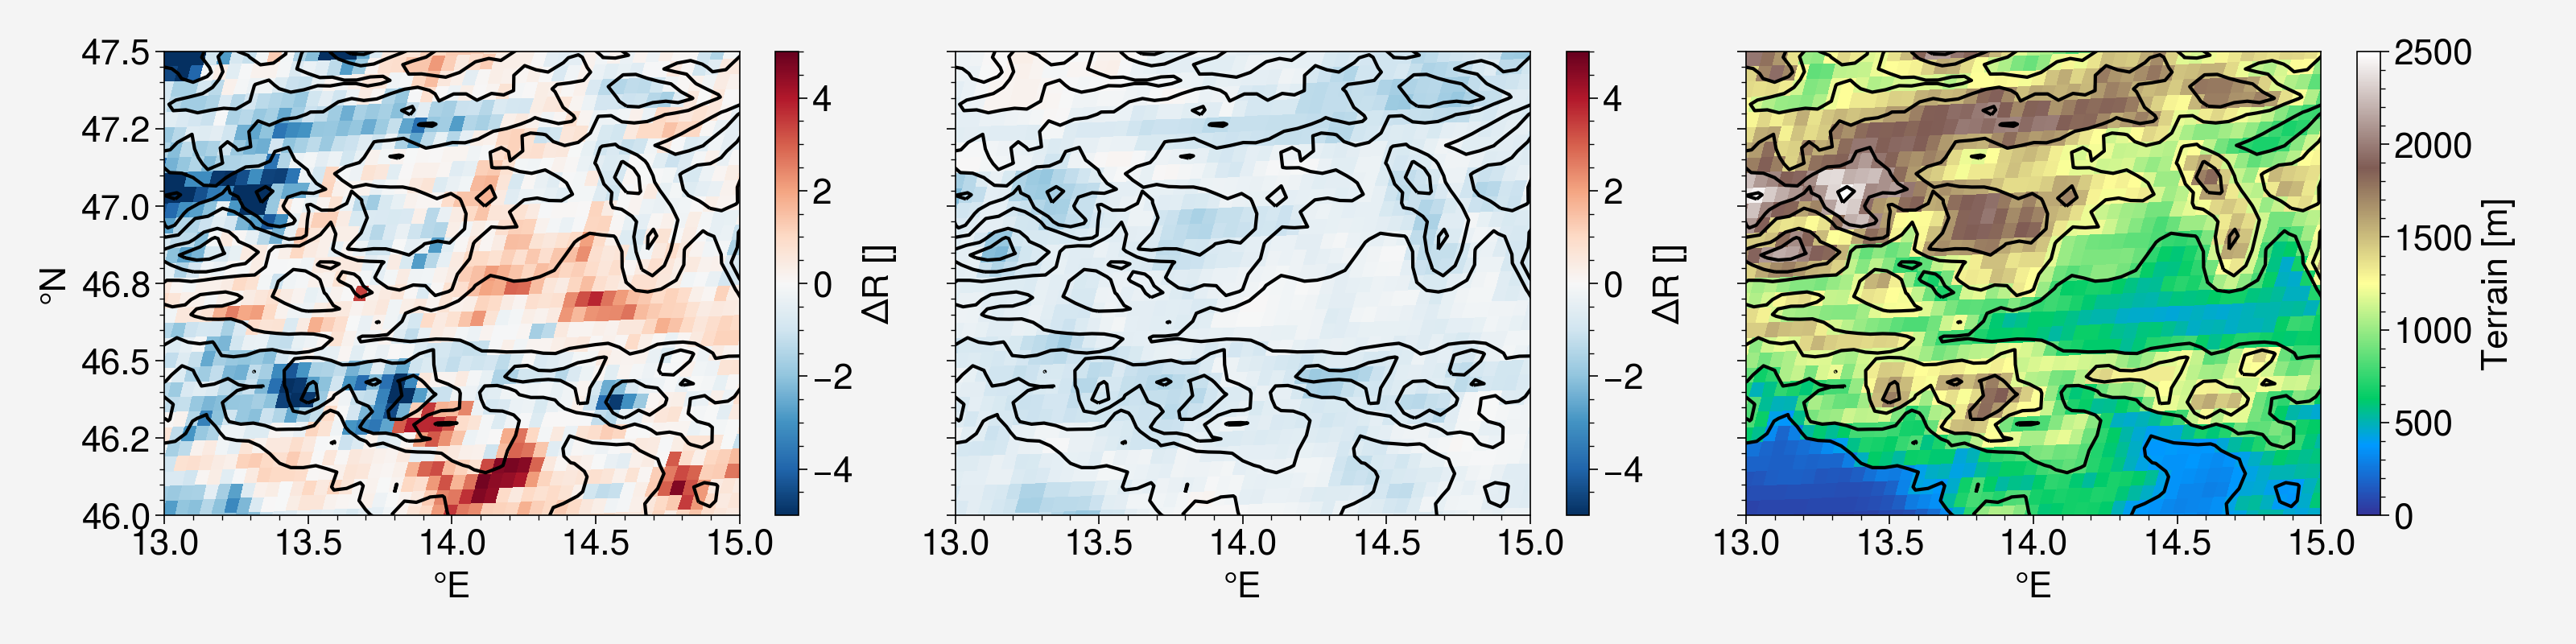

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- your existing slice and data prep ---
r1, r2 = 80, 150
c1, c2 = 240, 300
x = LON[r1:r2, c1:c2]
y = LAT[r1:r2, c1:c2]
z_terrain = H[r1:r2, c1:c2] * 1000

diff_O = o06[r1:r2, c1:c2] - o15[r1:r2, c1:c2]
diff_B = b06[r1:r2, c1:c2] - b15[r1:r2, c1:c2]

# --- create a 1×3 figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True)
plt.rcParams.update({'font.size': 16})

# common formatter for lon/lat
for ax in axes:
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
    ax.set_xlim(13, 15)
    ax.set_ylim(46., 47.5)
    ax.set_xlabel("°E")
axes[0].set_ylabel("°N")

# --- panel 1: O difference ---
pcm1 = axes[0].pcolormesh(x, y, diff_O*100.,
                          vmin=-5, vmax=5,
                          cmap='RdBu_r', shading='auto')
cbar1 = fig.colorbar(pcm1, ax=axes[0], label="ΔR []")
#cont1 = axes[0].contour(x, y, z_terrain,
#                       levels=5, color='black', linewidths=1.8)
CS = axes[0].contour(x, y, z_terrain, levels=[400,800,1200,1600], colors='black')

# cl = axes[0].clabel(CS, CS.levels, fmt='%10.0f', inline=True, fontsize=12,inline_spacing=-5)

# CS = axes[0].contour(x, y, z_terrain, levels=[2000,2400], colors='red')
CS = axes[0].contour(x, y, z_terrain, levels=[2000,2400], colors='black')
# axes[0].clabel(CS, fmt='%1.0f', fontsize=12,inline=True,inline_spacing=-5)
# axes[0].set_title("(c) Terrain")

# CS = axes[0].contour(x, y, z_terrain, colors='black')

# axes[0].clabel(CS, CS.levels, fmt='%10.0f', fontsize=12)
# #axes[0].clabel(cont1, inline=True, colors='black', fmt='%10.0f')
# CS = axes[0].contour(x, y, z_terrain, levels=[2000], colors='red')
# axes[0].clabel(CS, fmt='%1.1f', fontsize=12)
# axes[0].set_title("(a) O(6 UTC) - O(15 UTC)")

# --- panel 2: B difference ---
pcm2 = axes[1].pcolormesh(x, y, diff_B*100.,
                          vmin=-5, vmax=5,
                          cmap='RdBu_r', shading='auto')
cbar2 = fig.colorbar(pcm2, ax=axes[1], label="ΔR []")
# CS = axes[1].contour(x, y, z_terrain, colors='black')
# # axes[1].clabel(CS, CS.levels, fmt='%10.0f', inline=True, fontsize=12)
# # axes[1].clabel(CS, CS.levels, fmt='%10.0f', fontsize=12)
# CS = axes[1].contour(x, y, z_terrain, levels=[2000], colors='red')
# axes[1].clabel(CS, fmt='%1.1f', fontsize=12)
# axes[1].set_title("(b) B(6 UTC) - B(15 UTC)")
CS = axes[1].contour(x, y, z_terrain, levels=[400,800,1200,1600], colors='black')

# cl = axes[1].clabel(CS, CS.levels, fmt='%10.0f', inline=True, fontsize=12,inline_spacing=-5)

# CS = axes[1].contour(x, y, z_terrain, levels=[2000,2400], colors='red')
CS = axes[1].contour(x, y, z_terrain, levels=[2000,2400], colors='black')
# axes[1].clabel(CS, fmt='%1.0f', fontsize=12,inline=True,inline_spacing=-5)
# --- panel 3: terrain ---
pcm3 = axes[2].pcolormesh(x, y, z_terrain,
                          vmin=0, vmax=2500,
                          cmap='terrain', shading='auto')
cbar3 = fig.colorbar(pcm3, ax=axes[2], label="Terrain [m]")
CS = axes[2].contour(x, y, z_terrain, levels=[400,800,1200,1600], colors='black')

# cl = axes[2].clabel(CS, CS.levels, fmt='%10.0f', inline=True, fontsize=12,inline_spacing=-5)

# CS = axes[2].contour(x, y, z_terrain, levels=[2000,2400], colors='red')
CS = axes[2].contour(x, y, z_terrain, levels=[2000,2400], colors='black')
# axes[2].clabel(CS, fmt='%1.0f', fontsize=12,inline=True,inline_spacing=-5)
# axes[2].set_title("(c) Terrain")

# --- layout & save ---
plt.tight_layout()
plt.subplots_adjust(top=0.92)   # if you need more room for suptitle/legends
# plt.savefig("/home/km4c/to_ucloud/shadow_effects.png", dpi=1200)
plt.subplots_adjust(wspace=0.1)
plt.show()

In [29]:
fig.savefig('../../figs/20250919-hight.pdf',bbox_inches='tight')

In [26]:
CS.levels

array([2000., 2400.])

## Maps

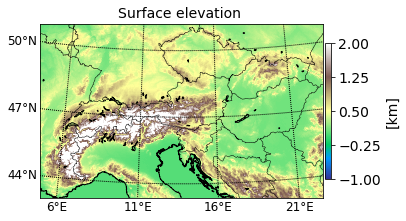

In [5]:
fig = geo_map_vis([H], ["Surface elevation"], cmaps=["terrain"],
            date="", unit="[km]",
            lon=rttov122.data.lon_obs_map.values, 
            lat=rttov122.data.lat_obs_map.values,
            vmin=-1.0, vmax=2.0,save=True,shrink=0.5,
            out_path='/home/km4c/to_ucloud/',
            name='surface_elevation'
            )

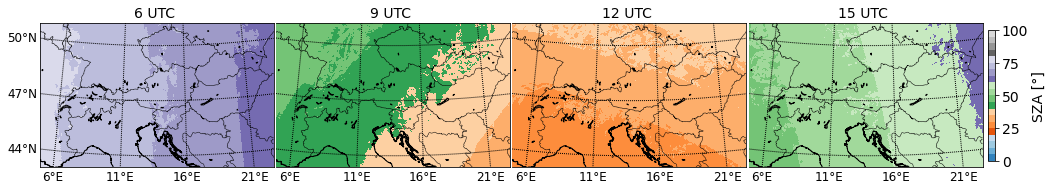

In [3]:
out_1 = rttov122.angles["SZA"]['060000'].values*domain_mask
out_2 = rttov122.angles["SZA"]['090000'].values*domain_mask
out_3 = rttov122.angles["SZA"]['120000'].values*domain_mask
out_4 = rttov122.angles["SZA"]['150000'].values*domain_mask

fig = geo_map_vis([out_1, out_2, out_3, out_4], ["6 UTC", "9 UTC", "12 UTC", "15 UTC"], cmaps=["tab20c", "tab20c","tab20c", "tab20c"],
            date="", unit="SZA [°]",
            lon=rttov122.data.lon_obs_map.values, lat=rttov122.data.lat_obs_map.values,
            vmin=0.0, vmax=100,save=True,
            out_path='/home/km4c/to_ucloud/',shrink=0.2,
            name=f'SZA_map_all_hours'
            )

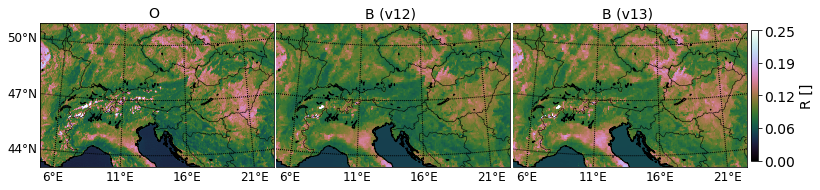

In [2]:
hours = ['060000','090000','120000','150000']
hour = '120000'
out_1 = visop.clear_observed[hour].values*domain_mask
out_2 = rttov122.clear_synthetic["darkest-pixel"][hour].values*domain_mask
out_3 = rttov132.clear_synthetic["darkest-pixel"][hour].values*domain_mask

fig = geo_map_vis([out_1, out_2, out_3], ["O", "B (v12)", "B (v13)"], cmaps=["cubehelix", "cubehelix","cubehelix"],
            date="", unit="R []",
            lon=rttov122.data.lon_obs_map.values, lat=rttov122.data.lat_obs_map.values,
            vmin=0.0, vmax=0.25,save=True,shrink=0.2,
            out_path='/home/km4c/to_ucloud/',
            name=f'Clr_Ref_map_{hour}'
            )

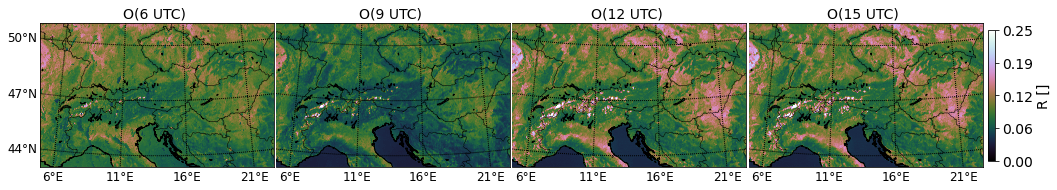

In [3]:
out_1 = visop.clear_observed['060000'].values*domain_mask
out_2 = visop.clear_observed['090000'].values*domain_mask
out_3 = visop.clear_observed['120000'].values*domain_mask
out_4 = visop.clear_observed['120000'].values*domain_mask

fig = geo_map_vis([out_1, out_2, out_3, out_4], ["O(6 UTC)", "O(9 UTC)", "O(12 UTC)", "O(15 UTC)"], cmaps=["cubehelix", "cubehelix","cubehelix", "cubehelix"],
            date="", unit="R []",
            lon=rttov122.data.lon_obs_map.values, lat=rttov122.data.lat_obs_map.values,
            vmin=0.0, vmax=0.25,save=True,
            out_path='/home/km4c/to_ucloud/',shrink=0.2,
            name=f'Clr_Ref_map_all_hours'
            )

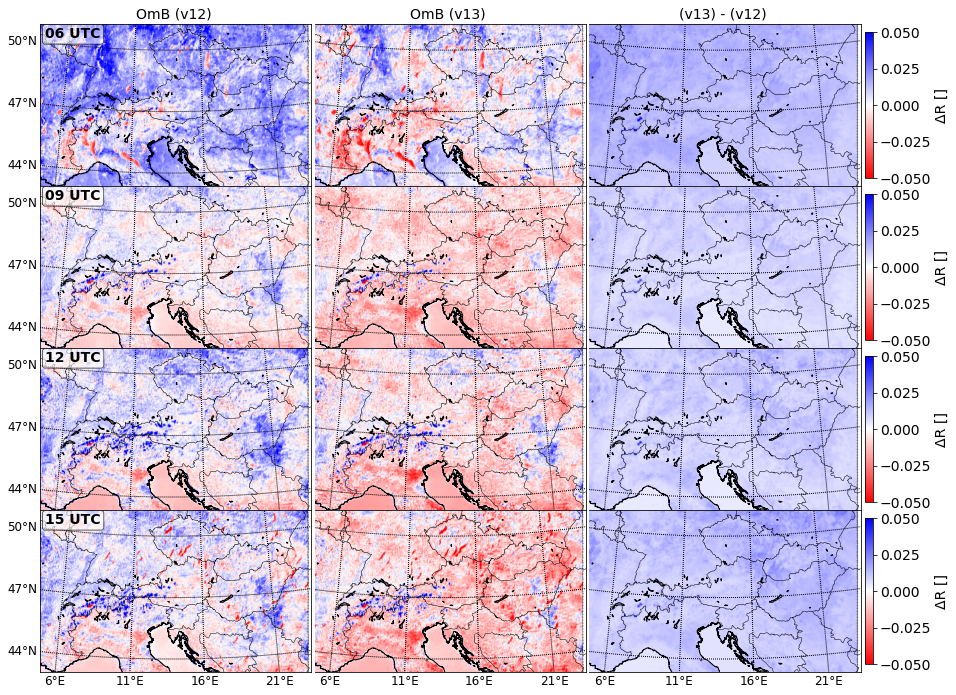

In [95]:
fig_OmB, axes = plt.subplots(4, 3,
                             figsize=(15,10),
                             constrained_layout=False)
fig_OmB.subplots_adjust(top=0.95,
                        bottom=0.05,
                        left=0.05,
                        right=0.95,
                        wspace=0.01,
                        hspace=0.0)

# split your rows
axes_rows = [axes[i, :] for i in range(4)]

for hour, ax_row in zip(hours, axes_rows):
    # compute out_1, out_2, out_3 as before…
    out_1 = visop.clear_observed[hour].values*domain_mask
    out_2 = rttov122.clear_synthetic["darkest-pixel"][hour].values*domain_mask
    out_3 = rttov132.clear_synthetic["darkest-pixel"][hour].values*domain_mask
    cmaps=["bwr_r", "bwr_r","bwr_r"]
    if hour == "060000":
        names=["OmB (v12)", "OmB (v13)", "(v13) - (v12)"]
    else:
        names = ["", "", ""]
    axs_flat = geo_map_vis([out_1-out_2, out_1-out_3, out_3-out_2],
                            names,
                            cmaps=cmaps,
                            lon=rttov122.data.lon_obs_map.values, 
                            lat=rttov122.data.lat_obs_map.values,
                            vmin=-0.05, vmax=0.05,
                            shrink=0.9,
                            date="",
                            unit="ΔR []",
                            axes=ax_row,
                            fig=fig_OmB)
    ax = ax_row[0]
    ax.text(0.02, 0.98, f"{hour[:-4]} UTC",
            transform=ax.transAxes,
            va='top', ha='left',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))
plt.show()

In [99]:
fig_OmB.savefig('my_OmB_comparison.png',
                dpi=300,
                bbox_inches='tight')

## OmB dependence on angles, terrain, albedo

In [30]:
all_dfs = [] # All dataframes includes dataframe of data at each selected hour
df_v1 = []
df_v2 = []
df_v3 = []

correction_filters = {
    "default": lambda T12: flatten_data(H) < np.inf,  # No correction
    "v1": lambda T12: ~(flatten_data(SZA) > 75), # Exclude pixels with sza > 75 degrees
    "v2": lambda T12: ~(flatten_data(H) > 2), # Exclude pixels with terrain > 2 km
    "v3": lambda T12: ~((flatten_data(SZA) > 75) | (flatten_data(H) > 2)), # Exlude pixels either > 2 km or sza > 75 degrees
}

def flatten_data(x):
    y1 = x.flatten()
    y2 = y1[~np.isnan(y1)]
    return y2

time_slice = ["060000","090000","120000","150000"]
#time_slice = ["060000"]
for hour in time_slice:

    sza = flatten_data(rttov122.angles["SZA"][hour].values*domain_mask)
    vza = flatten_data(rttov122.angles["VZA"][hour].values*domain_mask)
    sca = flatten_data(rttov122.angles["SCA"][hour].values*domain_mask)
    albedo = flatten_data(rttov122.albedo_from_atlas[hour].values*domain_mask)
    terrain = flatten_data(H)
    obs = visop.clear_observed[hour].values*domain_mask
    omb1 = flatten_data(obs) - flatten_data(rttov122.clear_synthetic["darkest-pixel"][hour].values*domain_mask)
    omb2 = flatten_data(obs) - flatten_data(rttov132.clear_synthetic["darkest-pixel"][hour].values*domain_mask)
   
    # filter out departures larger than 0.05 to remove pixels most likely affected by misreprested snow whether in O or B
    SZA = rttov122.angles["SZA"][hour].values*domain_mask
    mask_f1 = correction_filters["default"](omb2)
    
    df1 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb1[mask_f1]}) # V122
    df2 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb2[mask_f1]}) # V132
    all_dfs.extend([df1, df2])

    
    mask_f1 = correction_filters["v1"](omb2)
    df1 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb1[mask_f1]}) # V122
    df2 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb2[mask_f1]}) # V132
    df_v1.extend([df1, df2])

    mask_f1 = correction_filters["v2"](omb2)
    
    df1 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb1[mask_f1]}) # V122
    df2 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb2[mask_f1]}) # V132
    df_v2.extend([df1, df2])

    mask_f1 = correction_filters["v3"](omb2)
    
    df1 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb1[mask_f1]}) # V122
    df2 = pd.DataFrame({'SZA': sza[mask_f1], 'VZA': vza[mask_f1], 'albedo': albedo[mask_f1], 'terrain': terrain[mask_f1], 'SCA': sca[mask_f1], 'OmB': omb2[mask_f1]}) # V132
    df_v3.extend([df1, df2])

<function matplotlib.pyplot.show(close=None, block=None)>

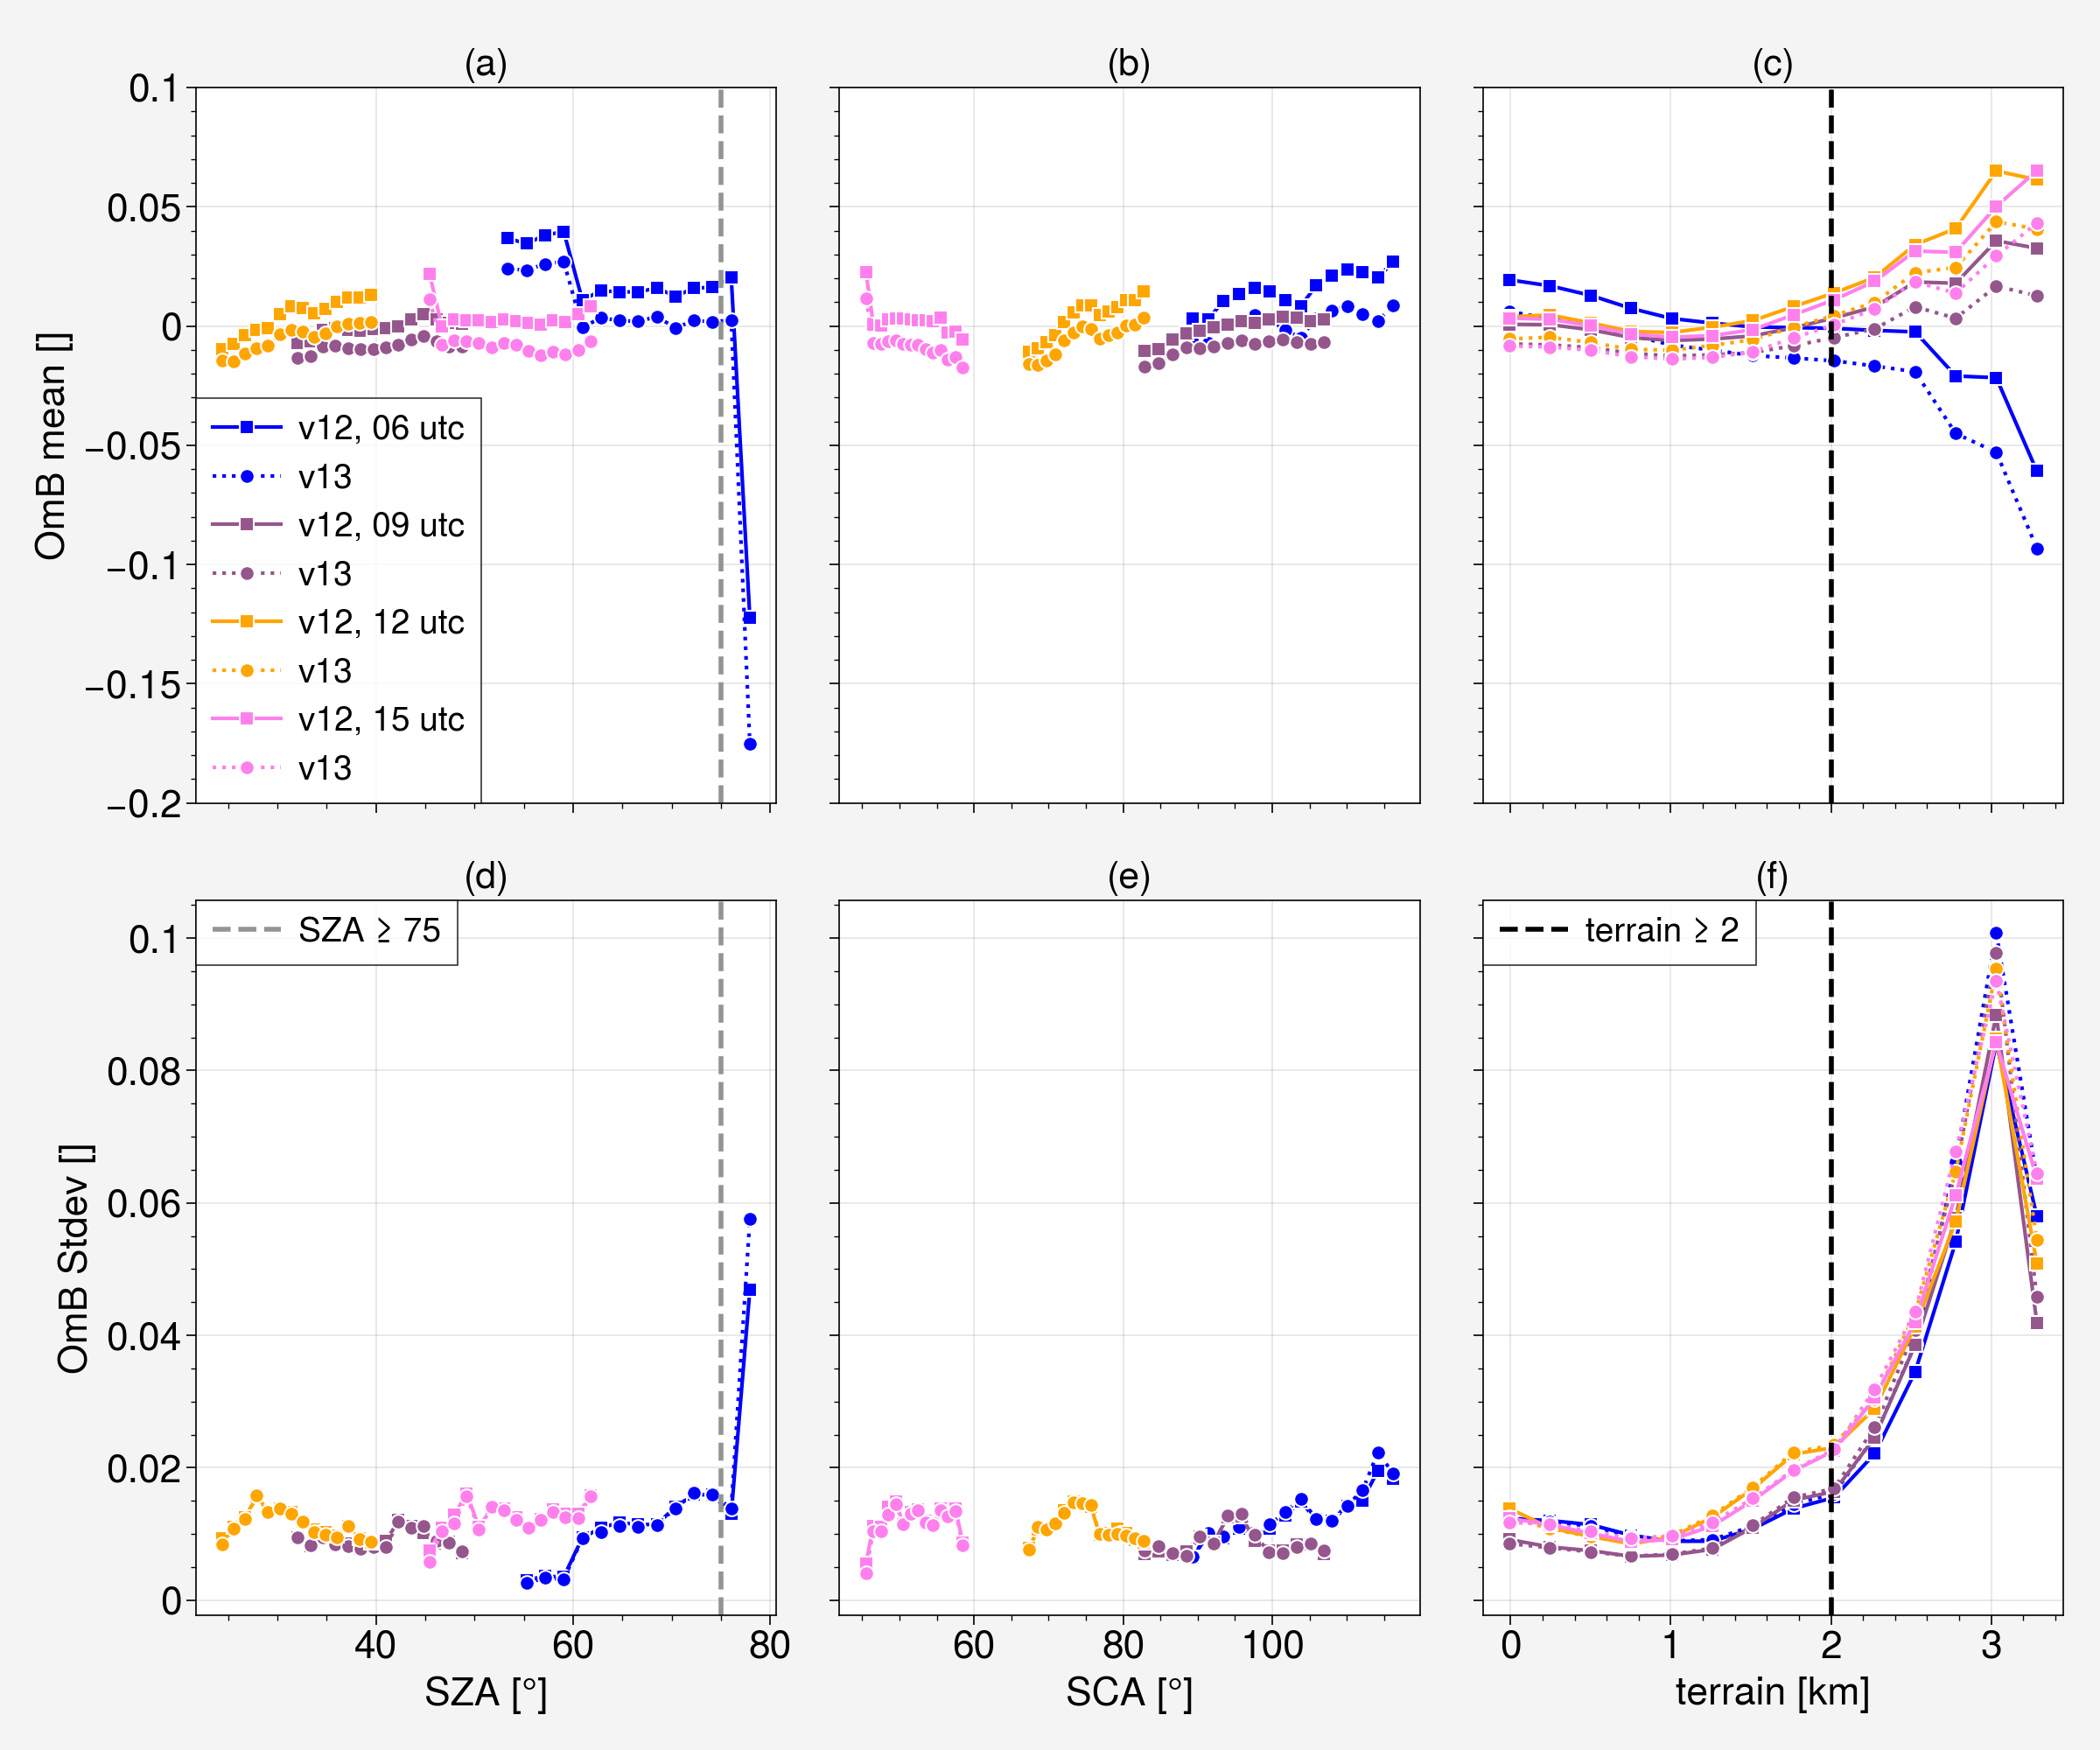

In [31]:
variables = ["SZA", "SCA", 'terrain'] # ['VZA', 'SZA', 'SCA', 'terrain']
units = ["[°]", "[°]", "[km]"]
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(12, 10), sharey='row')
plt.rcParams.update({'font.size': 14})

# Collect legend handles and labels
handles, labels = [], []

# Loop through each set of DataFrames
for set_num, (df1, df2) in enumerate(zip(all_dfs[::2], all_dfs[1::2])):
    data_list1 = [bin_data(df1.copy(), var) for var in variables]
    data_list2 = [bin_data(df2.copy(), var) for var in variables]
    current_color = set_colors[set_num]

    for i, var in enumerate(variables):
        # Plot mean bias
        if i == 0:
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-', label=f'v12, {time_slice[set_num][:2]} utc')
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         color=current_color, marker='o', linestyle='dotted', label=f'v13')
            # Collect handles and labels (only for the first subplot)
            handles, labels = axes[0, i].get_legend_handles_labels()
        else:
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-')
            sns.lineplot(ax=axes[0, i], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         color=current_color, marker='o', linestyle='dotted')

        axes[0, i].set_title(f'({chr(ord("a") + i)})')
        axes[0, i].set_ylabel('OmB mean []' if i == 0 else '')
        axes[0, i].set_xticklabels([])
        axes[0, i].set_xlabel('')
        axes[0, i].set_ylim(-0.2, 0.1)
        # Plot standard deviation
        sns.lineplot(ax=axes[1, i], x=var + '_bin', y='OmB_std', data=data_list1[i],
                     color=current_color, marker='s', linestyle='-')
        sns.lineplot(ax=axes[1, i], x=var + '_bin', y='OmB_std', data=data_list2[i],
                     color=current_color, marker='o', linestyle='dotted')
        axes[1, i].set_title(f'({chr(ord("a") + i + 3)})')
        axes[1, i].set_xlabel(var+" "+units[i])
        axes[1, i].set_ylabel('OmB Stdev []' if i == 0 else '')

for ax in axes.flatten():
    ax.grid(True)

# after drawing the vlines on the second row…
axes[0, 0].axvline(x=75, color='grey', linestyle='--', linewidth=2, label="SZA ≥ 75")
axes[0, 2].axvline(x=2,  color='black', linestyle='--', linewidth=2, label="terrain ≥ 2")
axes[1, 0].axvline(x=75, color='grey', linestyle='--', linewidth=2, label="SZA ≥ 75")
axes[1, 2].axvline(x=2,  color='black', linestyle='--', linewidth=2, label="terrain ≥ 2")

# now put legends on *those* axes:
axes[1, 0].legend(loc='upper left')
axes[1, 2].legend(loc='upper left')

plt.tight_layout()
plt.subplots_adjust(top=0.95)  # Adjust top spacing to accommodate the legend
plt.show
# plt.savefig('/home/km4c/to_ucloud/OmB_stats_angles_terrain.png')

<function matplotlib.pyplot.show(close=None, block=None)>

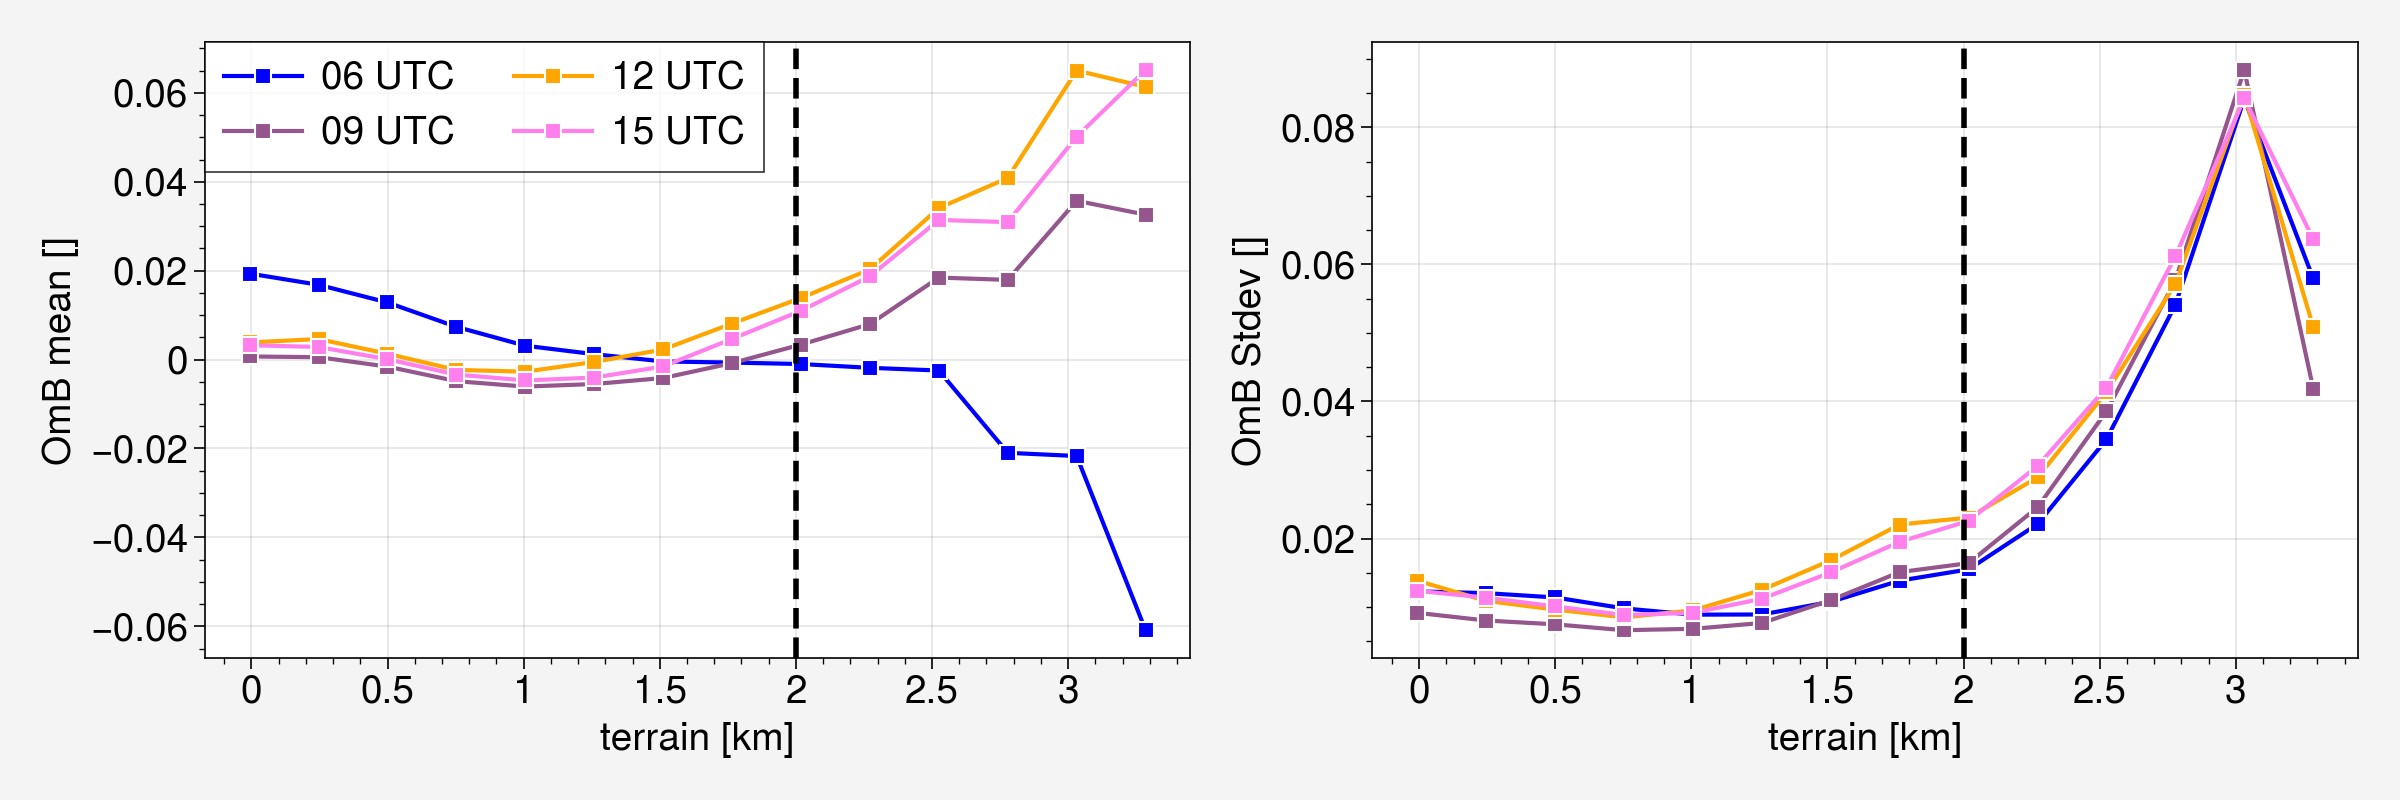

In [47]:
# variables = ["SZA", "SCA", 'terrain'] # ['VZA', 'SZA', 'SCA', 'terrain']
variables = [ 'terrain'] # ['VZA', 'SZA', 'SCA', 'terrain']
# units = ["[°]", "[°]", "[km]"]
units = [ "[km]"]
set_colors = ['blue', 'purple', '#ffa500','#ff80ed', 'orange']
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4),sharex=True)

# Collect legend handles and labels
handles, labels = [], []

# Loop through each set of DataFrames
for set_num, (df1, df2) in enumerate(zip(all_dfs[::2], all_dfs[1::2])):
    data_list1 = [bin_data(df1.copy(), var) for var in variables]
    data_list2 = [bin_data(df2.copy(), var) for var in variables]
    current_color = set_colors[set_num]

    for i, var in enumerate(variables):
        # Plot mean bias
        if i == 0:
            sns.lineplot(ax=axes[0], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-', label=f'{time_slice[set_num][:2]} UTC')
            # sns.lineplot(ax=axes[0], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         # color=current_color, marker='o', linestyle='dotted', label=f'v13')
            # Collect handles and labels (only for the first subplot)
            handles, labels = axes[0].get_legend_handles_labels()
        else:
            sns.lineplot(ax=axes[0], x=var + '_bin', y='OmB_mean', data=data_list1[i],
                         color=current_color, marker='s', linestyle='-')
            # sns.lineplot(ax=axes[0], x=var + '_bin', y='OmB_mean', data=data_list2[i],
                         # color=current_color, marker='o', linestyle='dotted')

        # axes[0].set_title(f'({chr(ord("a") + i)})')
        axes[0].set_ylabel('OmB mean []' if i == 0 else '')
        # axes[0].set_xticklabels([])
        axes[0].set_xlabel(var+" "+units[i])
        # axes[0].set_xlabel('')
        # axes[0].set_ylim(-0.2, 0.1)
        # Plot standard deviation
        sns.lineplot(ax=axes[1], x=var + '_bin', y='OmB_std', data=data_list1[i],
                     color=current_color, marker='s', linestyle='-')
        # sns.lineplot(ax=axes[1], x=var + '_bin', y='OmB_std', data=data_list2[i],
                     # color=current_color, marker='o', linestyle='dotted')
        # axes[1].set_title(f'({chr(ord("a") + i + 3)})')
        axes[1].set_xlabel(var+" "+units[i])
        axes[1].set_ylabel('OmB Stdev []' if i == 0 else '')

# for ax in axes.flatten():
#     ax.grid(True)

# after drawing the vlines on the second row…
axes[0].axvline(x=2,  color='black', linestyle='--', linewidth=2)#, label="terrain ≥ 2")
axes[1].axvline(x=2,  color='black', linestyle='--', linewidth=2)#, label="terrain ≥ 2")

# now put legends on *those* axes:
axes[0].legend(loc='upper left',ncol=2)
# axes[1].legend(loc='upper left')

plt.tight_layout()
# plt.subplots_adjust(top=0.95)  # Adjust top spacing to accommodate the legend
plt.show
# plt.savefig('/home/km4c/to_ucloud/OmB_stats_angles_terrain.png')

In [48]:
fig.savefig('../../figs/20250919-stat-terrain.pdf',bbox_inches='tight')